<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/Android_Ransomware_Detection_Alamgir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection Detection**

## **Font family setup**

In [1]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link:

## **Importing Dataset**

In [2]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/Android_Ransomeware.csv")

## **Basic Information**

In [4]:
df

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,2927,10.42.0.151-10.42.0.1-53849-53-17,10.42.0.151,53849,10.42.0.1,53,17,23/08/2017 04:45:14,24707,1,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
392030,2928,10.42.0.151-96.126.100.203-34559-123-17,10.42.0.151,34559,96.126.100.203,123,17,23/08/2017 04:43:31,81388,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
392031,2929,10.42.0.151-10.42.0.1-23177-53-17,10.42.0.151,23177,10.42.0.1,53,17,23/08/2017 04:43:38,61591,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
392032,2930,10.42.0.151-10.42.0.1-30407-53-17,10.42.0.151,30407,10.42.0.1,53,17,23/08/2017 04:44:56,24831,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker


In [5]:
df.shape

(392034, 86)

In [6]:
df['Label'].value_counts()

,count
Label,
SVpeng,54161
PornDroid,46082
Koler,44555
Benign,43091
RansomBO,39859
Charger,39551
Simplocker,36340
WannaLocker,32701
Jisut,25672


## **Data Samples per Class**

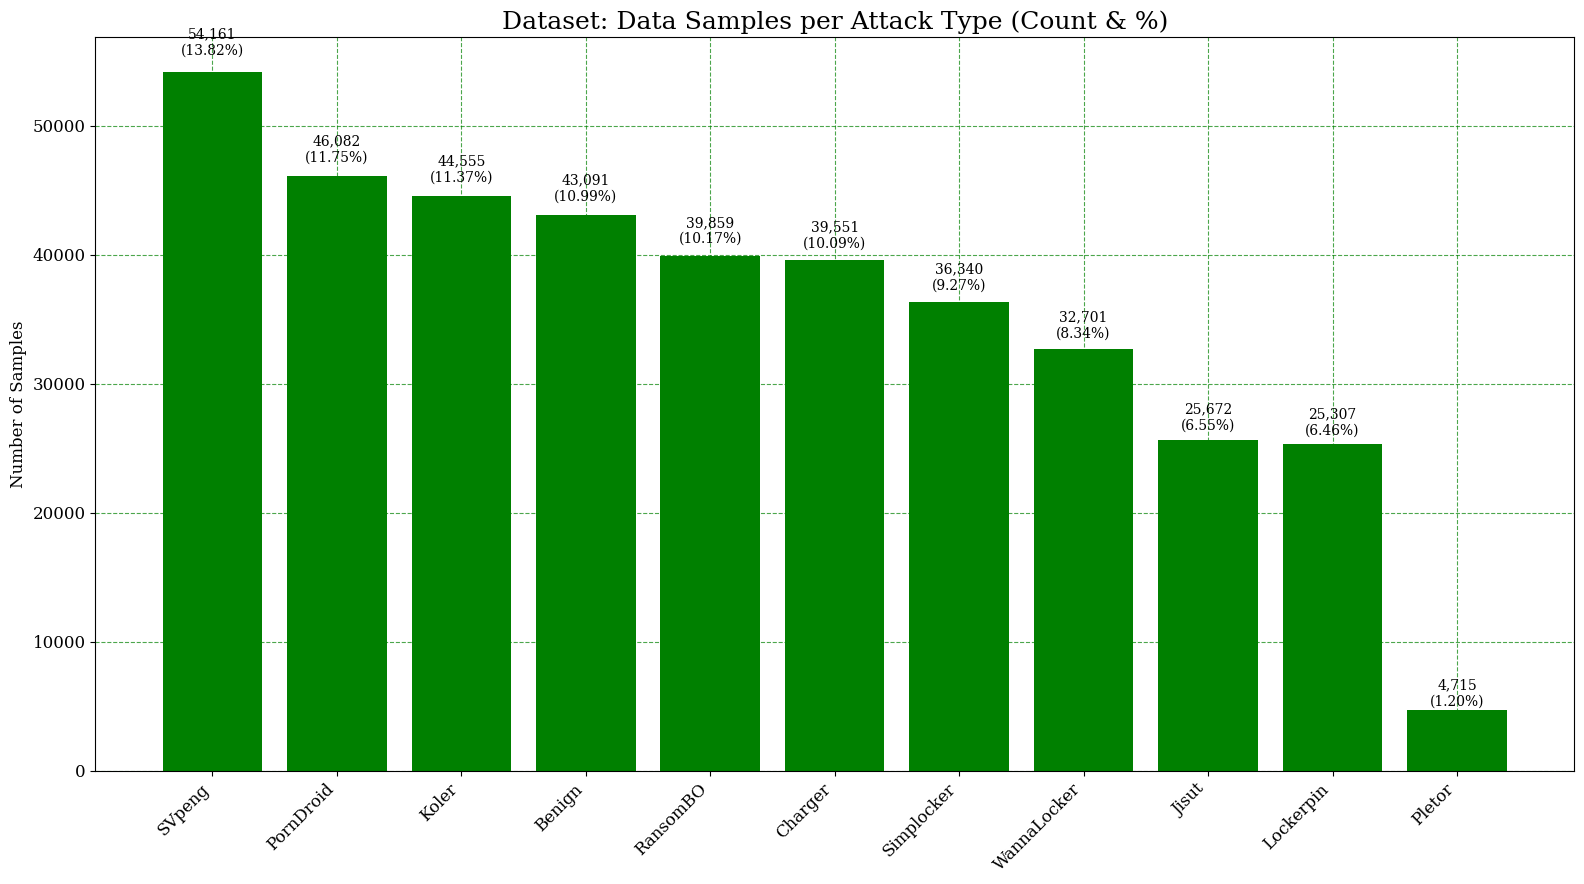

In [7]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Handle Missing Values**

In [8]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill missing values in categorical columns with mode
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled



Columns with Missing Values:
 Series([], dtype: int64)
Missing values after filling:
 0


In [9]:
# Print the names of the features (columns)
print(df.columns)

Index(['Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port',
       ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp',
       ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Len

## **Data Preprocessing**

In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ১. ইনফিনিটি এবং গারবেজ ভ্যালু ক্লিন করা
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)
df.dropna(inplace=True)

# ২. Numerical কলাম আলাদা করা (Label বাদ দিয়ে)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.difference(['Label'])

# ৩. ফিচার স্কেলিং (শুধু Numerical ফিচারে)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# ৪. Categorical কলাম আলাদা করা (Label বাদ দিয়ে)
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Label'])

# ৫. Categorical এনকোডিং (সব কলাম স্ট্রিং নিশ্চিত করে)
df[cat_cols] = df[cat_cols].astype(str)
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)



print("Preprocessing Success!")
print(df['Label'].value_counts()) # চেক করুন শুধু ০ এবং ১ আছে কি না


Preprocessing Success!
Label
SVpeng         54161
PornDroid      46082
Koler          44555
Benign         43091
RansomBO       39859
Charger        39551
Simplocker     36340
WannaLocker    32701
Jisut          25672
Lockerpin      25307
Pletor          4715
Name: count, dtype: int64


In [11]:
df

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-1.298572,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.479042,-0.032246,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
1,-1.297878,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.485900,-0.151883,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
2,-1.297185,148227,14,-0.238766,1294,-0.358896,-0.515637,7,-0.485911,-0.151883,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
3,-1.296491,142970,14,0.903302,1247,-0.358896,-0.515637,8,-0.484230,-0.181792,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
4,-1.295797,151270,14,0.330548,1328,-0.358896,-0.515637,9,-0.477782,-0.032246,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,0.731696,26058,13,0.814087,19,-0.384353,1.874255,27131,-0.484792,-0.181792,...,0.002826,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392030,0.732390,53062,13,-0.222643,4986,-0.379784,1.874255,27059,-0.482212,-0.181792,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392031,0.733083,15022,13,-0.834362,19,-0.384353,1.874255,27064,-0.483113,-0.181792,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392032,0.733777,17539,13,-0.445790,19,-0.384353,1.874255,27120,-0.484786,-0.181792,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker


## **After Processing**

In [12]:
df['Label'].value_counts()

,count
Label,
SVpeng,54161
PornDroid,46082
Koler,44555
Benign,43091
RansomBO,39859
Charger,39551
Simplocker,36340
WannaLocker,32701
Jisut,25672


In [13]:
####Copy the processed df to different df

df1 = df.copy()
df2 = df.copy()

# **Binary Class (Anomaly) Classification**

In [14]:
# বাইনারি ক্লাসিফিকেশনের জন্য লেবেল রূপান্তর (যদি ০ Benign হয়)
# এটি করলে আপনার ১১টি ক্লাস ০ এবং ১ এ চলে আসবে
df1['Label'] = df1['Label'].apply(lambda x: "Benign" if x == "Benign" else "Ransomware")

# Check counts
print(df1['Label'].value_counts())

# Define label and feature columns
X = df1.drop(columns=['Label','Unnamed: 0'])
y = df1['Label']

Label
Ransomware    348943
Benign         43091
Name: count, dtype: int64


In [15]:
X.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.479042,-0.032246,-0.008793,...,0.086747,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
1,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.485900,-0.151883,-0.107620,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
2,148227,14,-0.238766,1294,-0.358896,-0.515637,7,-0.485911,-0.151883,-0.107620,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
3,142970,14,0.903302,1247,-0.358896,-0.515637,8,-0.484230,-0.181792,-0.095267,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
4,151270,14,0.330548,1328,-0.358896,-0.515637,9,-0.477782,-0.032246,-0.021147,...,0.086747,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464


## **Traing and Test Division**

In [16]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.3,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (274423, 84)
X_test shape:  (117611, 84)
y_train shape: (274423,)
y_test shape:  (117611,)


Feature selection

In [17]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# ১. লেবেলগুলোকে অবশ্যই পূর্ণসংখ্যা (Integer) হতে হবে
# আপনার লেবেলে যদি -১.৫৪ টাইপ ভ্যালু থাকে, সেগুলোকে ০ এবং ১-এ বদলে নিন
#y_train_int = y_train.astype(int)

# ২. Random Forest মডেল (ইমব্যালেন্স ডাটা হ্যান্ডেল করার জন্য)
rf_selector = RandomForestClassifier(
    n_estimators=100, # Number of trees in the forest
    random_state=42,  # For reproducibility
    class_weight='balanced' # Handles imbalanced classes
)

# ৩. ট্রেইন করা
rf_selector.fit(X_train, y_train)

# ৪. এখন ইম্পর্ট্যান্স চেক করুন
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

# ৫. সেরা ৪০টি ফিচারের নাম নেওয়া
top_40_features = importance_df.head(10)['Feature'].tolist()

print("Top 40 Features (Random Forest):")
print(importance_df.head(10))

Top 40 Features (Random Forest):
                     Feature  Importance
6                  Timestamp    0.810254
1                  Source IP    0.018682
0                    Flow ID    0.017275
3             Destination IP    0.011169
25              Flow IAT Min    0.009096
72    Init_Win_bytes_forward    0.008908
73   Init_Win_bytes_backward    0.008853
2                Source Port    0.005501
24              Flow IAT Max    0.005412
42             Fwd Packets/s    0.004975


/tmp/ipykernel_4979/3106006440.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


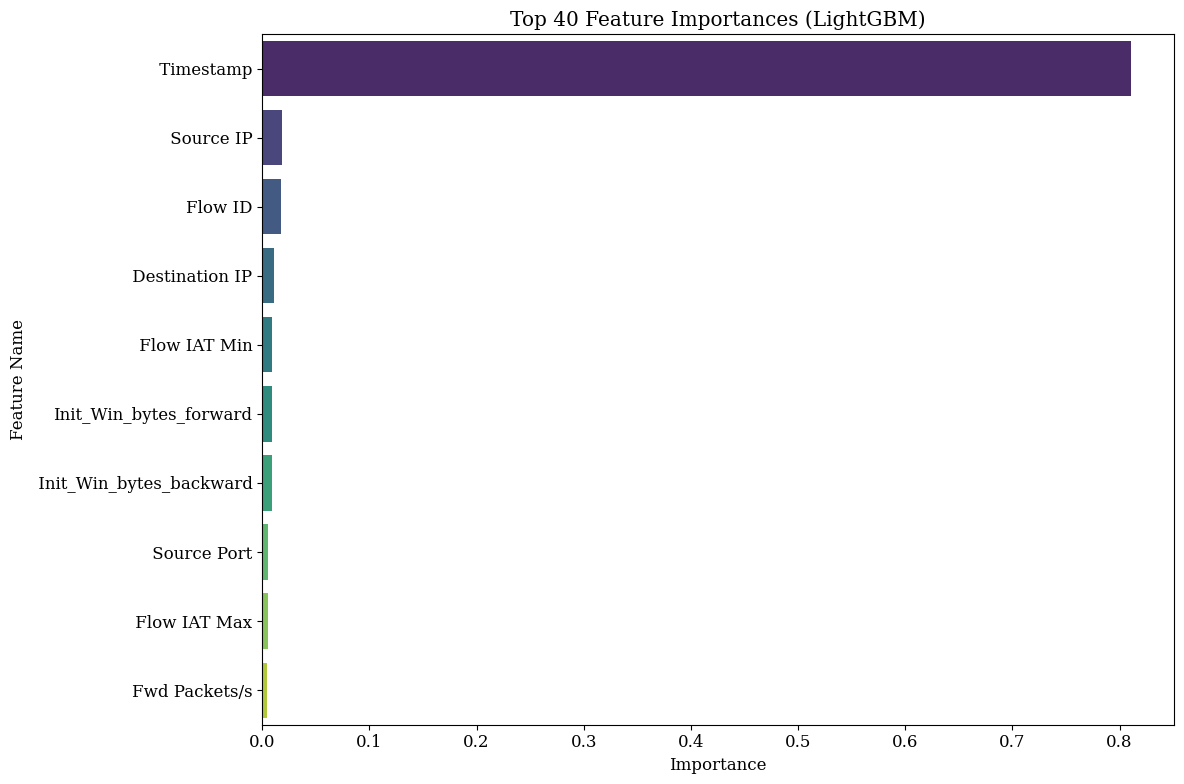

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 40 Feature Importances (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## **Train & Evaluate Decision Tree Classifier**

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


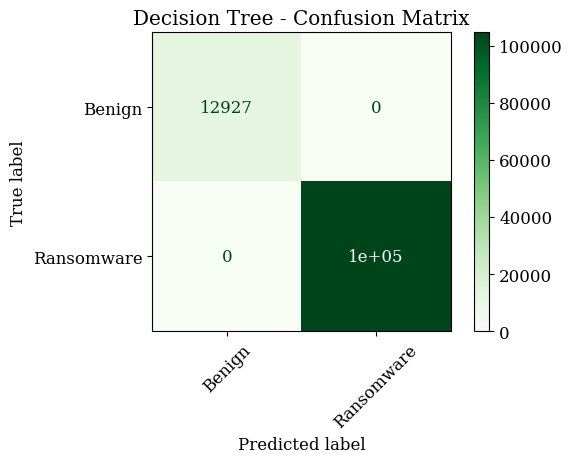

Classification Report:
              precision    recall  f1-score   support

      Benign    1.00000   1.00000   1.00000     12927
  Ransomware    1.00000   1.00000   1.00000    104684

    accuracy                        1.00000    117611
   macro avg    1.00000   1.00000   1.00000    117611
weighted avg    1.00000   1.00000   1.00000    117611



In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
X_train_sel = X_train[top_40_features]
X_test_sel = X_test[top_40_features]


# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_sel, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test_sel)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Random Forest Classifier**

Accuracy:  1.00000
Precision: 1.00000
Recall:    1.00000
F1 Score:  1.00000


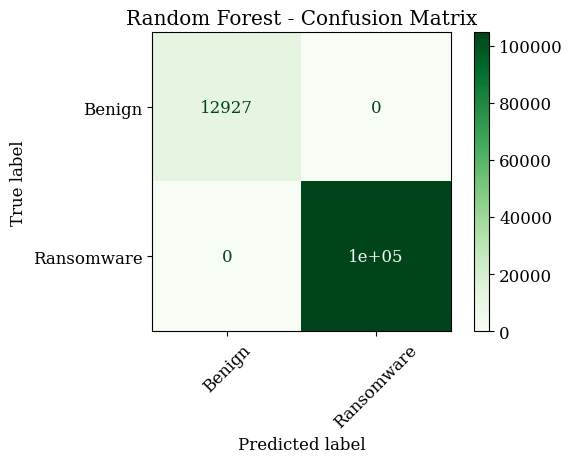

Classification Report:
              precision    recall  f1-score   support

      Benign    1.00000   1.00000   1.00000     12927
  Ransomware    1.00000   1.00000   1.00000    104684

    accuracy                        1.00000    117611
   macro avg    1.00000   1.00000   1.00000    117611
weighted avg    1.00000   1.00000   1.00000    117611



In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_train_sel, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test_sel)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.89565
Precision: 0.87985
Recall:    0.89565
F1 Score:  0.88471


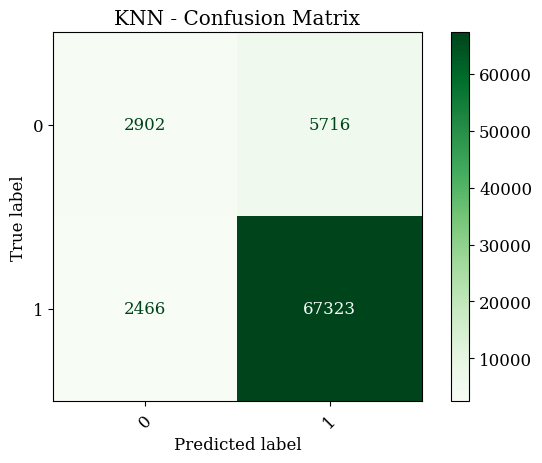

Classification Report:
              precision    recall  f1-score   support

           0    0.54061   0.33674   0.41499      8618
           1    0.92174   0.96466   0.94271     69789

    accuracy                        0.89565     78407
   macro avg    0.73118   0.65070   0.67885     78407
weighted avg    0.87985   0.89565   0.88471     78407



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=3)  # You can tune n_neighbors
knn_model.fit(X_train_sel, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test_sel)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Training Voting Classifier...
Voting Classifier training complete.

Voting Classifier Accuracy:  1.00000
Voting Classifier Precision: 1.00000
Voting Classifier Recall:    1.00000
Voting Classifier F1 Score:  1.00000


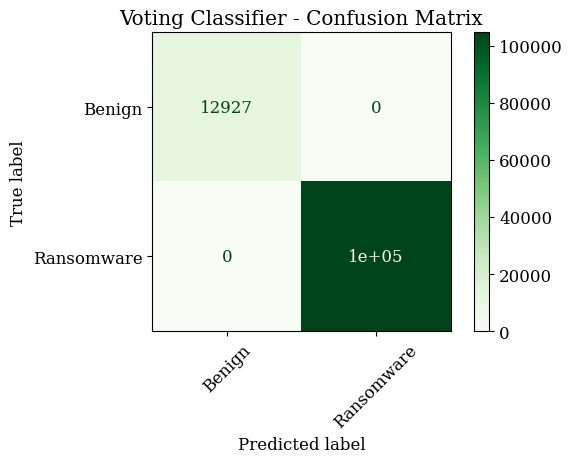

Voting Classifier Classification Report:
              precision    recall  f1-score   support

      Benign    1.00000   1.00000   1.00000     12927
  Ransomware    1.00000   1.00000   1.00000    104684

    accuracy                        1.00000    117611
   macro avg    1.00000   1.00000   1.00000    117611
weighted avg    1.00000   1.00000   1.00000    117611



In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Re-initialize individual classifiers for the VotingClassifier
# (using the best parameters found in previous cells if applicable,
# or default parameters if not explicitly optimized)

dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
knn_model = KNeighborsClassifier(n_neighbors=3)

# Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('dt', dt_model),
        ('rf', rf_model),
        ('knn', knn_model)
    ],
    voting='soft',  # 'hard' for majority vote, 'soft' for weighted average of probabilities
    n_jobs=-1
)

print("Training Voting Classifier...")
# Train the Voting Classifier
voting_clf.fit(X_train_sel, y_train)
print("Voting Classifier training complete.")

# Predict on Test Set
y_pred_voting = voting_clf.predict(X_test_sel)

# Evaluation Metrics
accuracy_voting = accuracy_score(y_test, y_pred_voting)
precision_voting = precision_score(y_test, y_pred_voting, average='weighted', zero_division=0)
recall_voting = recall_score(y_test, y_pred_voting, average='weighted', zero_division=0)
f1_voting = f1_score(y_test, y_pred_voting, average='weighted', zero_division=0)

# Print Basic Metrics (5-digit precision)
print(f"\nVoting Classifier Accuracy:  {accuracy_voting:.5f}")
print(f"Voting Classifier Precision: {precision_voting:.5f}")
print(f"Voting Classifier Recall:    {recall_voting:.5f}")
print(f"Voting Classifier F1 Score:  {f1_voting:.5f}")

# Confusion Matrix
cm_voting = confusion_matrix(y_test, y_pred_voting)
ConfusionMatrixDisplay(cm_voting, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Voting Classifier Classification Report:")
print(classification_report(y_test, y_pred_voting, zero_division=0, digits=5))

# **Multiclass Classification**

In [31]:
# Define label and feature columns
X = df2.drop(columns=['Label','Unnamed: 0'])
y = df2['Label']

## **Traing and Test Division**

In [23]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 85)
X_test shape:  (78407, 85)
y_train shape: (313627,)
y_test shape:  (78407,)


Top 40 Features for Multiclassification (Random Forest):
                     Feature  Importance
7                  Timestamp    0.387405
2                  Source IP    0.122896
0                 Unnamed: 0    0.076539
1                    Flow ID    0.063160
4             Destination IP    0.029607
3                Source Port    0.019205
26              Flow IAT Min    0.015981
8              Flow Duration    0.013351
25              Flow IAT Max    0.013296
23             Flow IAT Mean    0.012894
22            Flow Packets/s    0.012588
43             Fwd Packets/s    0.012426
73    Init_Win_bytes_forward    0.012266
31               Fwd IAT Min    0.010980
5           Destination Port    0.010961
27             Fwd IAT Total    0.009283
30               Fwd IAT Max    0.009015
28              Fwd IAT Mean    0.008877
44             Bwd Packets/s    0.008431
74   Init_Win_bytes_backward    0.007273


/tmp/ipykernel_4979/871475925.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_multi.head(20), palette='viridis')


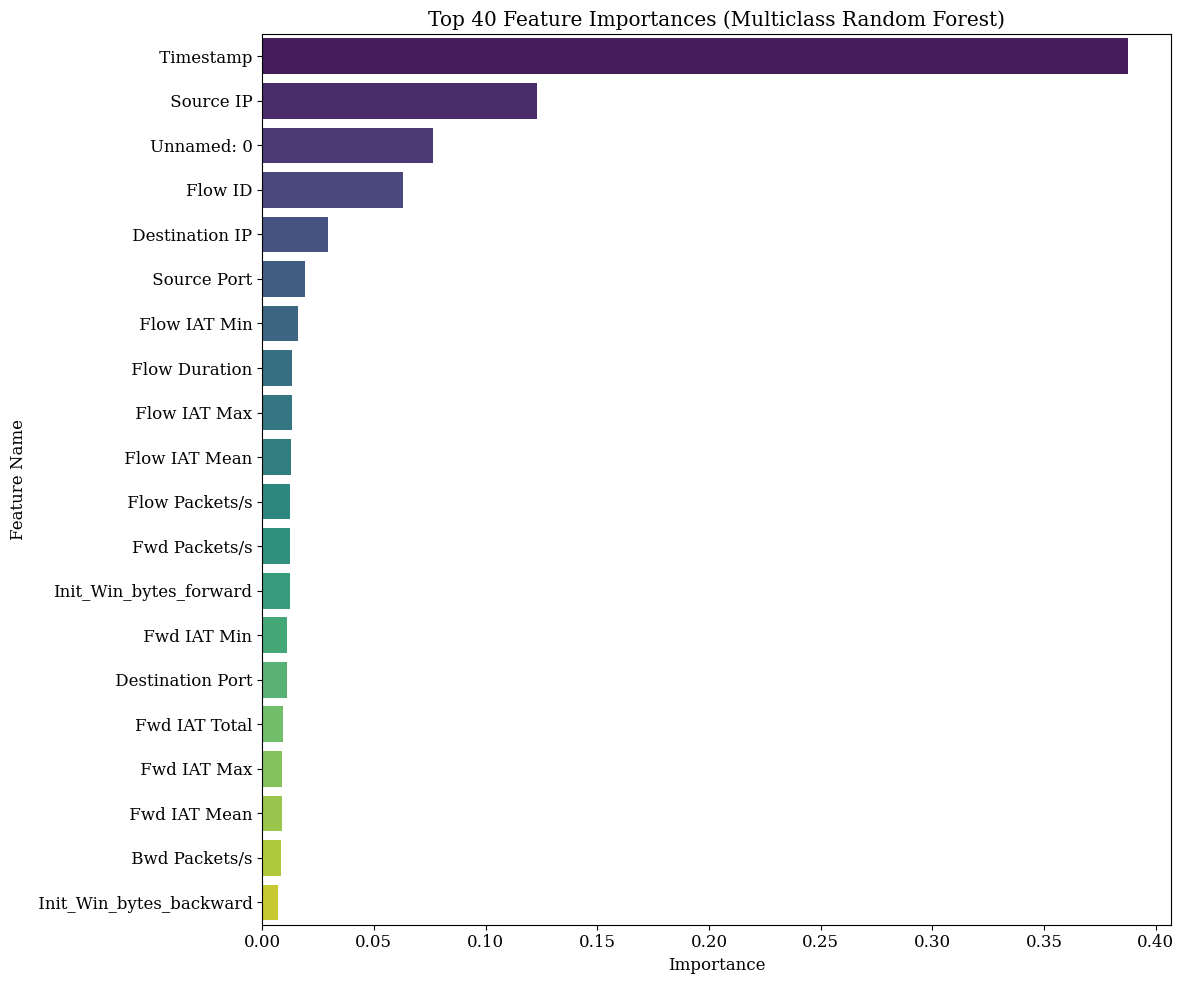

In [29]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Random Forest model for feature importance
rf_selector_multi = RandomForestClassifier(
    n_estimators=100, # Number of trees in the forest
    random_state=42,  # For reproducibility
    class_weight='balanced' # Handles imbalanced classes, important for multiclass
)

# 2. Train the model on the multiclass training data
rf_selector_multi.fit(X_train, y_train)

# 3. Get feature importances
importance_df_multi = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_selector_multi.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Select the top 40 features (adjust as needed)
top_40_features_multi = importance_df_multi.head(20)['Feature'].tolist()

print("Top 40 Features for Multiclassification (Random Forest):")
print(importance_df_multi.head(20))

# Plotting feature importances
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df_multi.head(20), palette='viridis')
plt.title('Top 40 Feature Importances (Multiclass Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

X_train_sel_multi = X_train[top_40_features_multi]
X_test_sel_multi = X_test[top_40_features_multi]

## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.9980
Precision: 0.9980
Recall:    0.9980
F1 Score:  0.9980


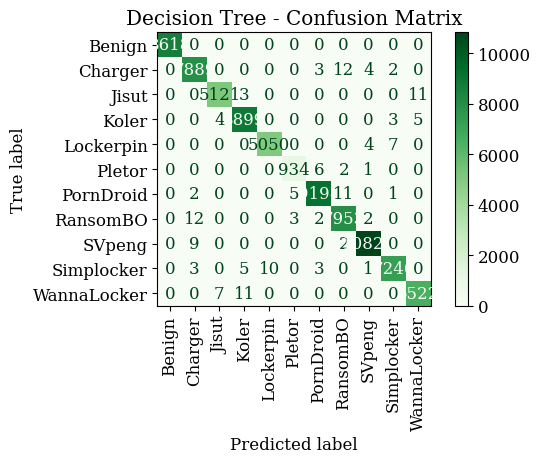

Classification Report:
              precision    recall  f1-score   support

      Benign    1.00000   1.00000   1.00000      8618
     Charger    0.99672   0.99735   0.99703      7910
       Jisut    0.99786   0.99727   0.99757      5135
       Koler    0.99787   0.99865   0.99826      8911
   Lockerpin    0.99802   0.99783   0.99793      5061
      Pletor    0.99151   0.99046   0.99098       943
   PornDroid    0.99848   0.99794   0.99821      9217
    RansomBO    0.99662   0.99762   0.99712      7972
      SVpeng    0.99889   0.99898   0.99894     10832
  Simplocker    0.99821   0.99697   0.99759      7268
 WannaLocker    0.99755   0.99725   0.99740      6540

    accuracy                        0.99801     78407
   macro avg    0.99743   0.99730   0.99737     78407
weighted avg    0.99801   0.99801   0.99801     78407



In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Training Multiclass Voting Classifier...
Multiclass Voting Classifier training complete.

Multiclass Voting Classifier Accuracy:  0.99830
Multiclass Voting Classifier Precision: 0.99830
Multiclass Voting Classifier Recall:    0.99830
Multiclass Voting Classifier F1 Score:  0.99830


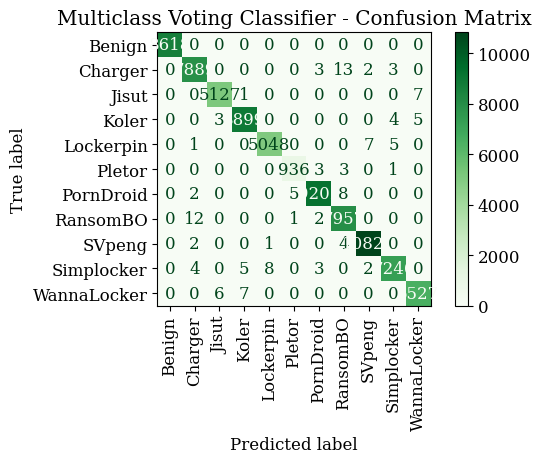

Multiclass Voting Classifier Classification Report:
              precision    recall  f1-score   support

      Benign    1.00000   1.00000   1.00000      8618
     Charger    0.99735   0.99735   0.99735      7910
       Jisut    0.99825   0.99844   0.99834      5135
       Koler    0.99854   0.99865   0.99860      8911
   Lockerpin    0.99822   0.99743   0.99783      5061
      Pletor    0.99363   0.99258   0.99310       943
   PornDroid    0.99881   0.99837   0.99859      9217
    RansomBO    0.99649   0.99812   0.99731      7972
      SVpeng    0.99898   0.99935   0.99917     10832
  Simplocker    0.99821   0.99697   0.99759      7268
 WannaLocker    0.99816   0.99801   0.99809      6540

    accuracy                        0.99830     78407
   macro avg    0.99788   0.99775   0.99781     78407
weighted avg    0.99830   0.99830   0.99830     78407



In [30]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Re-initialize individual classifiers for the VotingClassifier
# Using parameters from previously trained models or sensible defaults

dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Adjust n_estimators as needed
knn_model = KNeighborsClassifier(n_neighbors=5) # Using n_neighbors=5 as in previous KNN multiclassification

# Create the Voting Classifier
voting_clf_multi = VotingClassifier(
    estimators=[
        ('dt', dt_model),
        ('rf', rf_model),
        ('knn', knn_model)
    ],
    voting='soft',  # 'soft' for weighted average of probabilities (if supported by base estimators)
    n_jobs=-1,
    # Weights can be adjusted based on individual model performance
    # weights=[1, 1, 1] # Example weights if you want to assign them
)

print("Training Multiclass Voting Classifier...")
# Train the Voting Classifier on the selected features
voting_clf_multi.fit(X_train_sel_multi, y_train)
print("Multiclass Voting Classifier training complete.")

# Predict on Test Set using selected features
y_pred_voting_multi = voting_clf_multi.predict(X_test_sel_multi)

# Evaluation Metrics
accuracy_voting_multi = accuracy_score(y_test, y_pred_voting_multi)
precision_voting_multi = precision_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)
recall_voting_multi = recall_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)
f1_voting_multi = f1_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)

# Print Basic Metrics (5-digit precision)
print(f"\nMulticlass Voting Classifier Accuracy:  {accuracy_voting_multi:.5f}")
print(f"Multiclass Voting Classifier Precision: {precision_voting_multi:.5f}")
print(f"Multiclass Voting Classifier Recall:    {recall_voting_multi:.5f}")
print(f"Multiclass Voting Classifier F1 Score:  {f1_voting_multi:.5f}")

# Confusion Matrix
cm_voting_multi = confusion_matrix(y_test, y_pred_voting_multi)
ConfusionMatrixDisplay(cm_voting_multi, display_labels=voting_clf_multi.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Multiclass Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Multiclass Voting Classifier Classification Report:")
print(classification_report(y_test, y_pred_voting_multi, zero_division=0, digits=5))

## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.95203
Precision: 0.95208
Recall:    0.95203
F1 Score:  0.95168


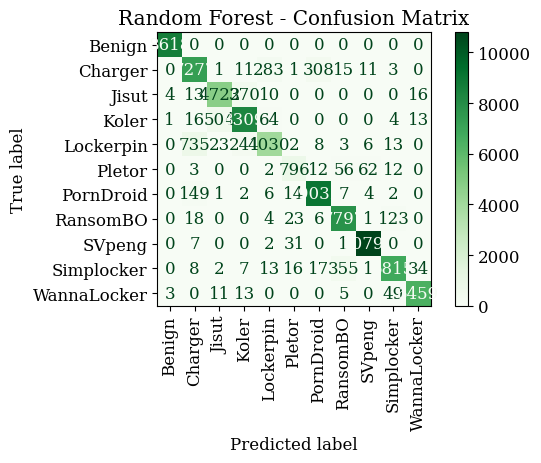

Classification Report:
              precision    recall  f1-score   support

      Benign    0.99907   1.00000   0.99954      8618
     Charger    0.88463   0.91997   0.90196      7910
       Jisut    0.89704   0.91957   0.90816      5135
       Koler    0.92807   0.93244   0.93025      8911
   Lockerpin    0.91300   0.79629   0.85066      5061
      Pletor    0.90147   0.84411   0.87185       943
   PornDroid    0.96259   0.97993   0.97118      9217
    RansomBO    0.94635   0.97805   0.96194      7972
      SVpeng    0.99218   0.99621   0.99420     10832
  Simplocker    0.97066   0.93767   0.95388      7268
 WannaLocker    0.99034   0.98761   0.98898      6540

    accuracy                        0.95203     78407
   macro avg    0.94413   0.93562   0.93933     78407
weighted avg    0.95208   0.95203   0.95168     78407



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.96185
Precision: 0.96191
Recall:    0.96185
F1 Score:  0.96186


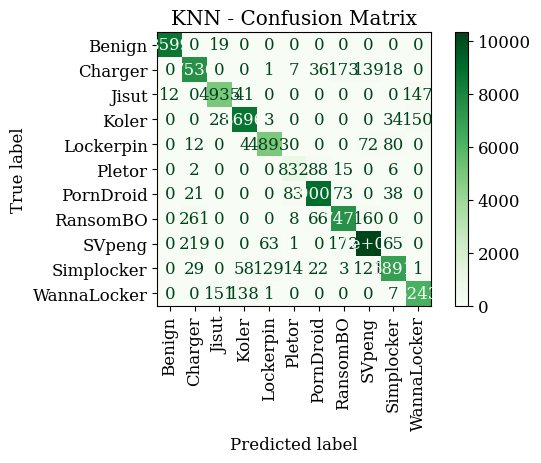

Classification Report:
              precision    recall  f1-score   support

      Benign    0.99861   0.99780   0.99820      8618
     Charger    0.93267   0.95272   0.94259      7910
       Jisut    0.96143   0.96105   0.96124      5135
       Koler    0.97303   0.97587   0.97445      8911
   Lockerpin    0.96130   0.96680   0.96404      5061
      Pletor    0.88042   0.88229   0.88136       943
   PornDroid    0.97699   0.97667   0.97683      9217
    RansomBO    0.94490   0.93791   0.94139      7972
      SVpeng    0.95446   0.95199   0.95323     10832
  Simplocker    0.96526   0.94813   0.95662      7268
 WannaLocker    0.95444   0.95459   0.95451      6540

    accuracy                        0.96185     78407
   macro avg    0.95487   0.95507   0.95495     78407
weighted avg    0.96191   0.96185   0.96186     78407



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Modified Confusion Matrix**

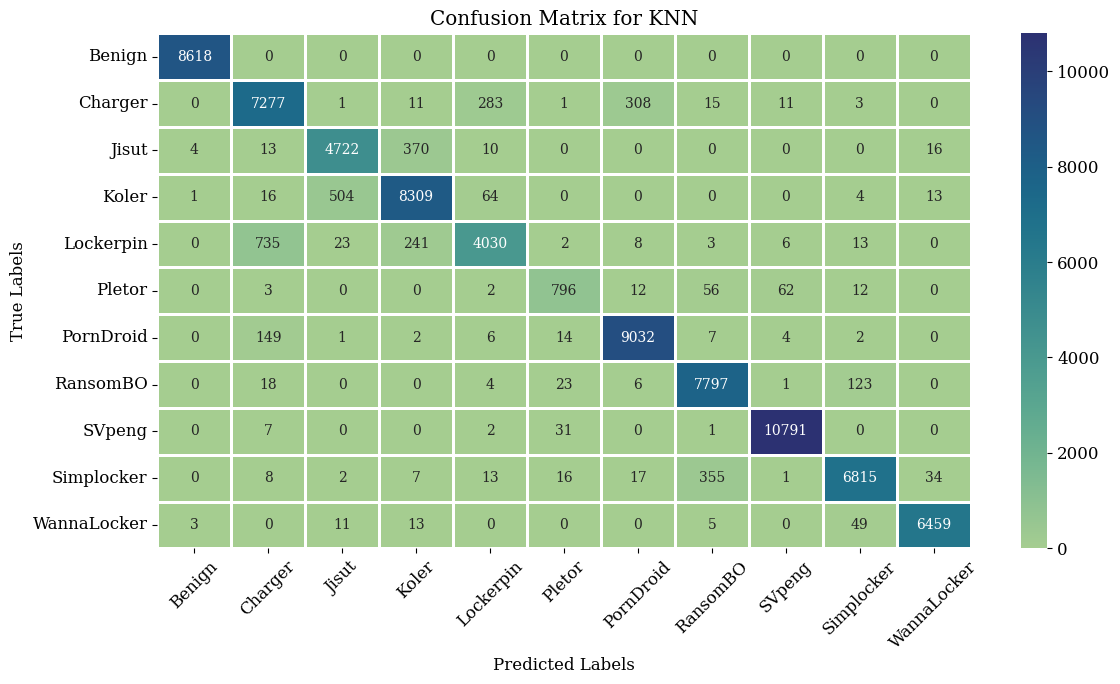

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Thank you Everyone!**